In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import time
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import layers, models

In [ ]:
dataset_path = "/content/drive/MyDrive/Retinopathy"

data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(224,224),
    batch_size=32,
    label_mode="int",
    shuffle=True
)

Found 3662 files belonging to 5 classes.


In [ ]:
total_size = len(data)

train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)

train_data = data.take(train_size)
temp_data = data.skip(train_size)

val_data = temp_data.take(val_size)
test_data = temp_data.skip(val_size)

In [ ]:
def get_preprocess_function(model_name):

    if model_name == "EfficientNet":
        from tensorflow.keras.applications.efficientnet import preprocess_input

    elif model_name == "ResNet":
        from tensorflow.keras.applications.resnet import preprocess_input

    elif model_name == "MobileNet":
        from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

    return preprocess_input

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

In [ ]:
def build_model(model_name):

    if model_name == "EfficientNet":
        base_model = tf.keras.applications.EfficientNetB0(
            weights='imagenet',
            include_top=False,
            input_shape=(224,224,3)
        )

    elif model_name == "ResNet":
        base_model = tf.keras.applications.ResNet50(
            weights='imagenet',
            include_top=False,
            input_shape=(224,224,3)
        )

    elif model_name == "MobileNet":
        base_model = tf.keras.applications.MobileNetV2(
            weights='imagenet',
            include_top=False,
            input_shape=(224,224,3)
        )

    for layer in base_model.layers[:-30]:
        layer.trainable = False

    x = base_model.output

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    # Attention layer
    attention = layers.Dense(512, activation='sigmoid')(x)
    x = layers.multiply([x, attention])

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(5, activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
import time

models_dict = {}
history_dict = {}
results = {}
training_times = {}

model_names = ["EfficientNet", "ResNet", "MobileNet"]

for name in model_names:
    print(f"\n Training {name}...\n")

    #getting correct preprocessing for each model
    preprocess_input = get_preprocess_function(name)

    def preprocess(x, y):
        x = tf.cast(x, tf.float32)
        x = preprocess_input(x)
        x.set_shape((None,224,224,3))
        return x, y

    # Apply preprocessing separately for each model
    train_p = train_data.map(preprocess).prefetch(tf.data.AUTOTUNE)
    val_p = val_data.map(preprocess).prefetch(tf.data.AUTOTUNE)
    test_p = test_data.map(preprocess).prefetch(tf.data.AUTOTUNE)

    #Build model
    model = build_model(name)

    #Start timer
    start_time = time.time()
    #Train model
    history = model.fit(
        train_p,
        validation_data=val_p,
        epochs=30,
        callbacks=[early_stop]
    )

    #End timer
    end_time = time.time()

    #Evaluate model (ONLY correct datasets)
    loss, val_acc = model.evaluate(val_p)
    test_loss, test_acc = model.evaluate(test_p)

    # Store everything
    models_dict[name] = model
    history_dict[name] = history
    results[name] = {
        "val_acc": val_acc,
        "test_acc": test_acc
    }
    training_times[name] = end_time - start_time


 Training EfficientNet...

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1203s 15s/step - accuracy: 0.7027 - loss: 0.8453 - val_accuracy: 0.7353 - val_loss: 0.7802
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 69s 872ms/step - accuracy: 0.7496 - loss: 0.6940 - val_accuracy: 0.7408 - val_loss: 0.6964
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 39s 494ms/step - accuracy: 0.7824 - loss: 0.6223 - val_accuracy: 0.7868 - val_loss: 0.5664
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 32s 406ms/step - accuracy: 0.7945 - loss: 0.5716 - val_accuracy: 0.7941 - val_loss: 0.5806
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 29s 367ms/step - accuracy: 0.8055 - loss: 0.5337 - val_accuracy: 0.7482 - val_loss: 0.6955
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 25s 318ms/step - accuracy: 0.8066 - loss: 0.5116 - val_accuracy: 0.7904 - val_loss: 0.6285
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 25s 316ms/step - accuracy: 0.8371 - loss: 0.4734 - val_accuracy: 0.7923 - val_loss: 0.6496
Epoch 8/30
80/80 ━

In [ ]:
df = pd.DataFrame({
    "Model": model_names,
    "Validation Accuracy": [results[m]["val_acc"] for m in model_names],
    "Test Accuracy": [results[m]["test_acc"] for m in model_names],
    "Training Time (s)": [training_times[m] for m in model_names]
})

print(df)   # When Epochs  = 30 & Patience  = 10 & Layers to train = 30

          Model  Validation Accuracy  Test Accuracy  Training Time (s)
0  EfficientNet             0.790441       0.810036        1537.596190
1        ResNet             0.656250       0.670251         269.087376
2     MobileNet             0.485294       0.482079         232.699152


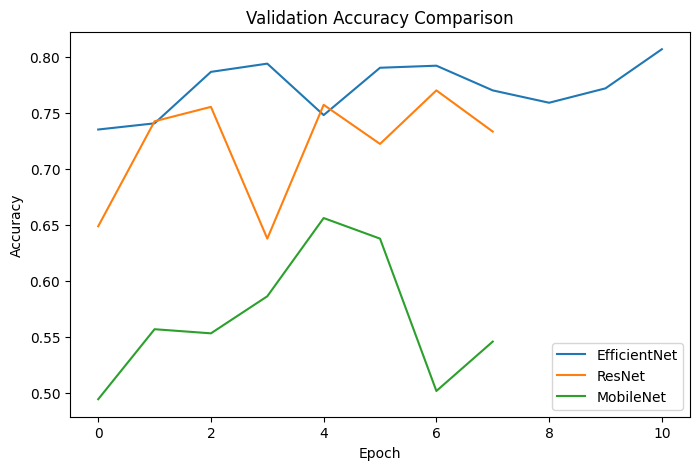

In [ ]:
plt.figure(figsize=(8,5))

for name in model_names:
    plt.plot(history_dict[name].history['val_accuracy'], label=name)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


Evaluating EfficientNet

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


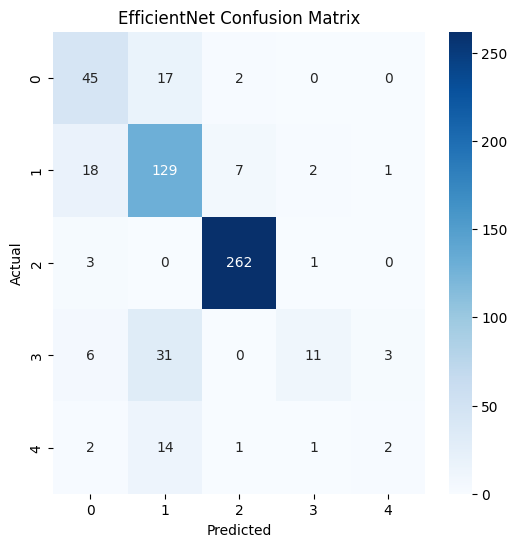

              precision    recall  f1-score   support

           0       0.61      0.70      0.65        64
           1       0.68      0.82      0.74       157
           2       0.96      0.98      0.97       266
           3       0.73      0.22      0.33        51
           4       0.33      0.10      0.15        20

    accuracy                           0.80       558
   macro avg       0.66      0.57      0.57       558
weighted avg       0.80      0.80      0.78       558


Evaluating ResNet

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

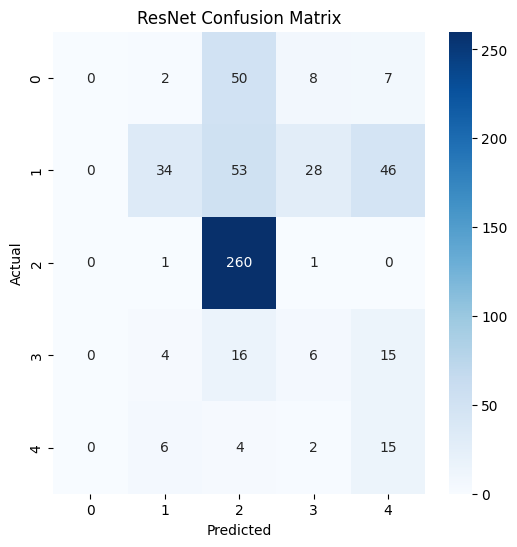

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        67
           1       0.72      0.21      0.33       161
           2       0.68      0.99      0.81       262
           3       0.13      0.15      0.14        41
           4       0.18      0.56      0.27        27

    accuracy                           0.56       558
   macro avg       0.34      0.38      0.31       558
weighted avg       0.55      0.56      0.50       558


Evaluating MobileNet



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


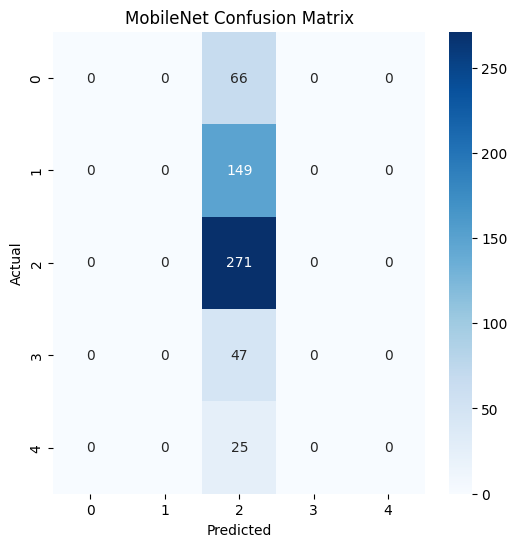

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        66
           1       0.00      0.00      0.00       149
           2       0.49      1.00      0.65       271
           3       0.00      0.00      0.00        47
           4       0.00      0.00      0.00        25

    accuracy                           0.49       558
   macro avg       0.10      0.20      0.13       558
weighted avg       0.24      0.49      0.32       558



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
for name in model_names:
    print(f"\nEvaluating {name}\n")

    model = models_dict[name]

    y_true = []
    y_pred = []

    for images, labels in test_data:
        preds = model.predict(images)
        preds = np.argmax(preds, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(y_true, y_pred))

In [ ]:
best_model_name = max(results, key=lambda x: results[x]["test_acc"])
best_model = models_dict[best_model_name]

print("Best Model:", best_model_name)

best_model.save("Best_DR_Model.keras")

Best Model: EfficientNet
